<a href="https://colab.research.google.com/github/RAHUL-REDDY-A/ML/blob/main/ml_lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ML_lab_08**\
reg no:bl.en.u4cse23102


LAB 08: PERCEPTRON AND NEURAL NETWORK IMPLEMENTATION

=== A2. AND Gate with Step Activation ===
Converged after 130 epochs with error 0
Final weights: [-0.1   0.1   0.05]
Testing AND Gate:
Input: [0, 0], Expected: 0, Predicted: 0
Input: [0, 1], Expected: 0, Predicted: 0
Input: [1, 0], Expected: 0, Predicted: 0
Input: [1, 1], Expected: 1, Predicted: 1


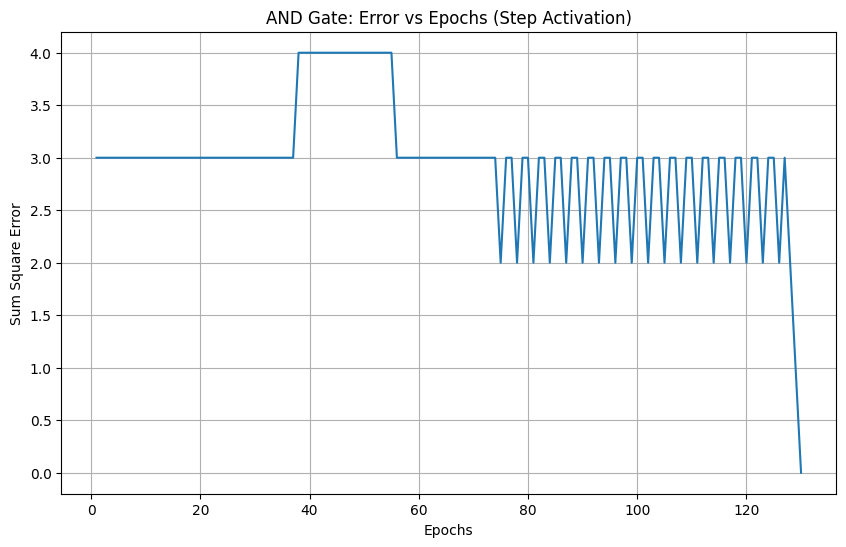


=== A3. AND Gate with Different Activations ===

Testing Bipolar Step activation:
Did not converge after 1000 epochs. Final error: 3
Final weights: [-0.1   0.1   0.05]
Testing results:
Input: [0, 0], Expected: 0, Predicted: -1
Input: [0, 1], Expected: 0, Predicted: -1
Input: [1, 0], Expected: 0, Predicted: 1
Input: [1, 1], Expected: 1, Predicted: 1

Testing Sigmoid activation:
Did not converge after 1000 epochs. Final error: 0.0419268541913846
Final weights: [-6.13531308  3.97083321  3.96394835]
Testing results:
Input: [0, 0], Expected: 0, Predicted: 0.0021603699783549974
Input: [0, 1], Expected: 0, Predicted: 0.10235157967622889
Input: [1, 0], Expected: 0, Predicted: 0.10298586517424319
Input: [1, 1], Expected: 1, Predicted: 0.8580842205857301

Testing ReLU activation:
Converged after 390 epochs with error 0.0019950963569777946
Final weights: [-0.92774472  0.95116001  0.94981086]
Testing results:
Input: [0, 0], Expected: 0, Predicted: 0
Input: [0, 1], Expected: 0, Predicted: 0.022066

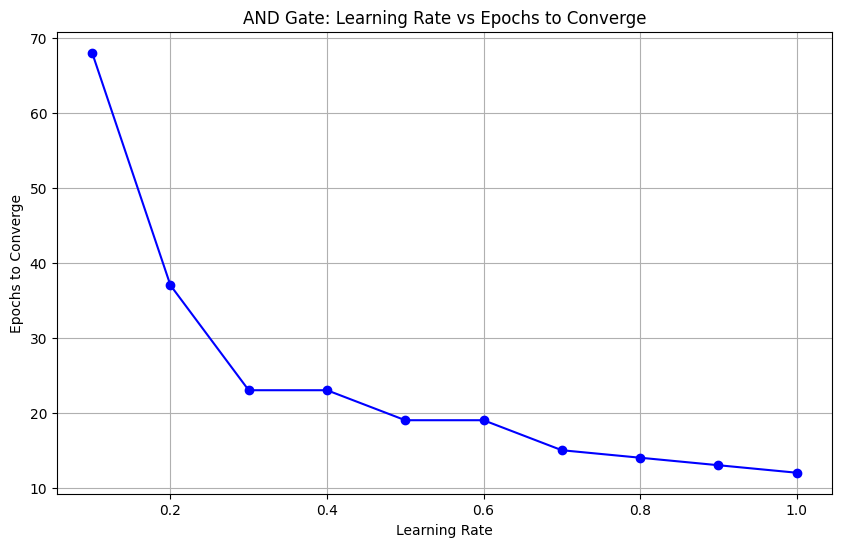


=== A5. XOR Gate Experiments ===
Note: Single-layer perceptron cannot learn XOR (not linearly separable)

Testing XOR with Step activation:
Did not converge after 1000 epochs. Final error: 4
Testing results:
Input: [0, 0], Expected: 0, Predicted: 1
Input: [0, 1], Expected: 1, Predicted: 0
Input: [1, 0], Expected: 1, Predicted: 0
Input: [1, 1], Expected: 0, Predicted: 0
Accuracy: 25.0%

Testing XOR with Bipolar Step activation:
Did not converge after 1000 epochs. Final error: 6
Testing results:
Input: [0, 0], Expected: 0, Predicted: 1
Input: [0, 1], Expected: 1, Predicted: 1
Input: [1, 0], Expected: 1, Predicted: 1
Input: [1, 1], Expected: 0, Predicted: -1
Accuracy: 50.0%

Testing XOR with Sigmoid activation:
Did not converge after 1000 epochs. Final error: 1.0254822313240348
Testing results:
Input: [0, 0], Expected: 0, Predicted: 0.507191810699878
Input: [0, 1], Expected: 1, Predicted: 0.5001433291793728
Input: [1, 0], Expected: 1, Predicted: 0.493820939278743
Input: [1, 1], Expected:

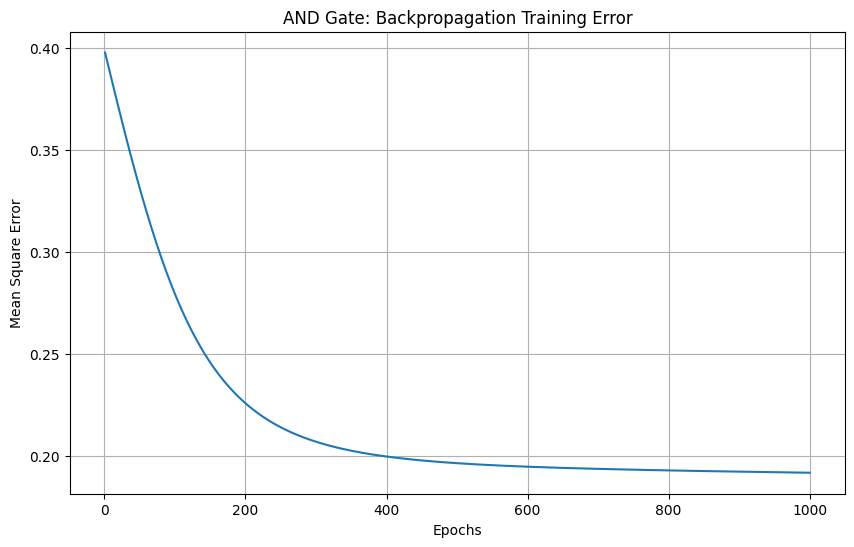


=== A9. Backpropagation NN for XOR Gate ===
Did not converge after 1000 epochs. Final error: 0.25004401425164857
Backpropagation XOR Gate Results:
Input: [0 0], Expected: 0, Predicted: 1
Input: [0 1], Expected: 1, Predicted: 1
Input: [1 0], Expected: 1, Predicted: 0
Input: [1 1], Expected: 0, Predicted: 0
XOR Accuracy: 50.0%

=== A10. NN with 2 Output Nodes ===
Did not converge after 1000 epochs. Final error: 0.1890546315347055
AND Gate with 2 outputs:
Input: [0 0], Expected: [1 0], Predicted: [0.73980706 0.26911096], Class: 0
Input: [0 1], Expected: [1 0], Predicted: [0.741831  0.2753874], Class: 0
Input: [1 0], Expected: [1 0], Predicted: [0.73269933 0.24806792], Class: 0
Input: [1 1], Expected: [0 1], Predicted: [0.73459303 0.25354152], Class: 0
Did not converge after 1000 epochs. Final error: 0.2501420905731368

XOR Gate with 2 outputs:
Input: [0 0], Expected: [1 0], Predicted: [0.51224814 0.50731906], Class: 0
Input: [0 1], Expected: [0 1], Predicted: [0.51708589 0.50868691], Cla

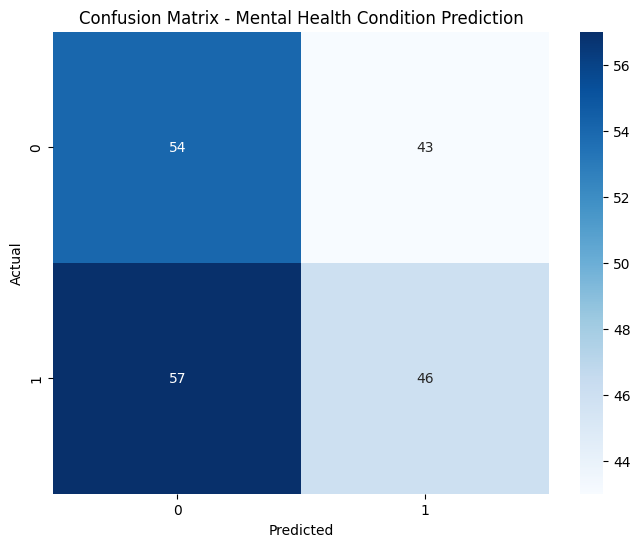


EXPERIMENT RESULTS SUMMARY
A2. AND Gate (Step): 130 epochs
A3. AND Gate Activation Comparison:
    Bipolar Step: 1001 epochs
    Sigmoid: 1001 epochs
    ReLU: 390 epochs
A4. Learning Rate Analysis: See plot above
A5. XOR Gate: Single perceptron cannot learn (not linearly separable)
A6. Customer Classification: 100.0% accuracy
A7. Pseudo-inverse vs Perceptron: 60.0% vs 100.0%
A8. Backpropagation AND Gate: 1000 epochs
A9. Backpropagation XOR Gate: 1000 epochs, 50.0% accuracy
A10. 2-Output XOR: 1000 epochs, 50.0% accuracy
A11. MLP AND Gate: 100.0% accuracy
A11. MLP XOR Gate: 100.0% accuracy
A12. Mental Health Dataset: 50.0% accuracy

KEY OBSERVATIONS:
1. Single-layer perceptrons can learn linearly separable problems (AND) but not XOR
2. Multi-layer networks with backpropagation can learn non-linear patterns like XOR
3. Different activation functions have varying convergence rates
4. Learning rate affects both convergence speed and stability
5. Neural networks significantly outperform si

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# A1. BASIC PERCEPTRON COMPONENTS
# ============================================================================

def summation_unit(inputs, weights, bias=0):
    """Summation unit: computes weighted sum of inputs plus bias"""
    return np.dot(inputs, weights) + bias

def step_activation(x):
    """Step activation function"""
    return 1 if x >= 0 else 0

def bipolar_step_activation(x):
    """Bipolar step activation function"""
    return 1 if x >= 0 else -1

def sigmoid_activation(x):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def tanh_activation(x):
    """Hyperbolic tangent activation function"""
    return np.tanh(x)

def relu_activation(x):
    """ReLU activation function"""
    return max(0, x)

def leaky_relu_activation(x, alpha=0.01):
    """Leaky ReLU activation function"""
    return x if x > 0 else alpha * x

def sigmoid_derivative(x):
    """Derivative of sigmoid function"""
    s = sigmoid_activation(x)
    return s * (1 - s)

def comparator_unit_error(predicted, actual):
    """Comparator unit for error calculation"""
    return actual - predicted

def sum_square_error(predictions, targets):
    """Calculate sum of squared errors"""
    return np.sum((np.array(targets) - np.array(predictions)) ** 2)

# ============================================================================
# A2. PERCEPTRON IMPLEMENTATION
# ============================================================================

class Perceptron:
    def __init__(self, weights, learning_rate=0.05, activation_func=step_activation):
        self.weights = np.array(weights)  # [w0 (bias), w1, w2]
        self.learning_rate = learning_rate
        self.activation_func = activation_func
        self.errors = []

    def predict(self, inputs):
        """Make prediction for given inputs"""
        inputs_with_bias = np.array([1] + list(inputs))
        net_input = summation_unit(inputs_with_bias, self.weights)
        return self.activation_func(net_input)

    def train(self, training_data, max_epochs=1000, convergence_threshold=0.002):
        """Train the perceptron"""
        epoch = 0

        while epoch < max_epochs:
            epoch_error = 0
            predictions = []

            for inputs, target in training_data:
                prediction = self.predict(inputs)
                predictions.append(prediction)

                error = comparator_unit_error(prediction, target)
                epoch_error += error ** 2

                inputs_with_bias = np.array([1] + list(inputs))
                self.weights += self.learning_rate * error * inputs_with_bias

            self.errors.append(epoch_error)

            if epoch_error <= convergence_threshold:
                print(f"Converged after {epoch + 1} epochs with error {epoch_error}")
                break

            epoch += 1

        if epoch_error > convergence_threshold:
            print(f"Did not converge after {max_epochs} epochs. Final error: {epoch_error}")

        return epoch + 1, epoch_error

# ============================================================================
# A8-A10. BACKPROPAGATION NEURAL NETWORK
# ============================================================================

class BackpropagationNN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.05):
        np.random.seed(42)
        self.W1 = np.random.normal(0, 0.5, (input_size + 1, hidden_size))
        self.W2 = np.random.normal(0, 0.5, (hidden_size + 1, output_size))
        self.learning_rate = learning_rate
        self.errors = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        X_with_bias = np.column_stack([np.ones(X.shape[0]), X])

        self.z1 = np.dot(X_with_bias, self.W1)
        self.a1 = self.sigmoid(self.z1)

        self.a1_with_bias = np.column_stack([np.ones(self.a1.shape[0]), self.a1])

        self.z2 = np.dot(self.a1_with_bias, self.W2)
        self.a2 = self.sigmoid(self.z2)

        return self.a2

    def backward(self, X, y, output):
        m = X.shape[0]

        X_with_bias = np.column_stack([np.ones(X.shape[0]), X])

        delta2 = (output - y) * self.sigmoid_derivative(output)
        delta1 = np.dot(delta2, self.W2[1:].T) * self.sigmoid_derivative(self.a1)

        self.W2 -= self.learning_rate * np.dot(self.a1_with_bias.T, delta2) / m
        self.W1 -= self.learning_rate * np.dot(X_with_bias.T, delta1) / m

    def train(self, X, y, max_epochs=1000, convergence_threshold=0.002):
        for epoch in range(max_epochs):
            output = self.forward(X)

            error = np.mean((y - output) ** 2)
            self.errors.append(error)

            if error <= convergence_threshold:
                print(f"Converged after {epoch + 1} epochs with error {error}")
                return epoch + 1

            self.backward(X, y, output)

        print(f"Did not converge after {max_epochs} epochs. Final error: {error}")
        return max_epochs

    def predict(self, X):
        output = self.forward(X)
        return (output > 0.5).astype(int)

# ============================================================================
# MAIN EXPERIMENTS
# ============================================================================

def run_all_experiments():
    """Run all lab experiments"""

    # Training data
    and_gate_data = [([0, 0], 0), ([0, 1], 0), ([1, 0], 0), ([1, 1], 1)]
    xor_gate_data = [([0, 0], 0), ([0, 1], 1), ([1, 0], 1), ([1, 1], 0)]

    print("="*70)
    print("LAB 08: PERCEPTRON AND NEURAL NETWORK IMPLEMENTATION")
    print("="*70)

    # ========================================================================
    # A2. AND Gate with Step Activation
    # ========================================================================
    print("\n=== A2. AND Gate with Step Activation ===")
    perceptron_and = Perceptron([10, 0.2, -0.75], 0.05, step_activation)
    epochs_and, final_error = perceptron_and.train(and_gate_data)

    print(f"Final weights: {perceptron_and.weights}")
    print("Testing AND Gate:")
    for inputs, expected in and_gate_data:
        predicted = perceptron_and.predict(inputs)
        print(f"Input: {inputs}, Expected: {expected}, Predicted: {predicted}")

    # Plot error vs epochs
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(perceptron_and.errors) + 1), perceptron_and.errors)
    plt.title('AND Gate: Error vs Epochs (Step Activation)')
    plt.xlabel('Epochs')
    plt.ylabel('Sum Square Error')
    plt.grid(True)
    plt.show()

    # ========================================================================
    # A3. Different Activation Functions for AND Gate
    # ========================================================================
    print("\n=== A3. AND Gate with Different Activations ===")
    activation_functions = {
        'Bipolar Step': bipolar_step_activation,
        'Sigmoid': sigmoid_activation,
        'ReLU': relu_activation
    }

    results_and = {}
    for name, func in activation_functions.items():
        print(f"\nTesting {name} activation:")
        perceptron = Perceptron([10, 0.2, -0.75], 0.05, func)
        epochs, final_error = perceptron.train(and_gate_data)
        results_and[name] = epochs

        print(f"Final weights: {perceptron.weights}")
        print("Testing results:")
        for inputs, expected in and_gate_data:
            predicted = perceptron.predict(inputs)
            print(f"Input: {inputs}, Expected: {expected}, Predicted: {predicted}")

    # ========================================================================
    # A4. Varying Learning Rates for AND Gate
    # ========================================================================
    print("\n=== A4. AND Gate with Different Learning Rates ===")
    learning_rates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    lr_results = {}

    for lr in learning_rates:
        perceptron = Perceptron([10, 0.2, -0.75], lr, step_activation)
        epochs, final_error = perceptron.train(and_gate_data)
        lr_results[lr] = epochs
        print(f"Learning Rate: {lr}, Epochs to converge: {epochs}")

    # Plot learning rate vs epochs
    plt.figure(figsize=(10, 6))
    plt.plot(list(lr_results.keys()), list(lr_results.values()), 'bo-')
    plt.title('AND Gate: Learning Rate vs Epochs to Converge')
    plt.xlabel('Learning Rate')
    plt.ylabel('Epochs to Converge')
    plt.grid(True)
    plt.show()

    # ========================================================================
    # A5. XOR Gate with Different Activations
    # ========================================================================
    print("\n=== A5. XOR Gate Experiments ===")
    print("Note: Single-layer perceptron cannot learn XOR (not linearly separable)")

    results_xor = {}
    for name, func in [('Step', step_activation)] + list(activation_functions.items()):
        print(f"\nTesting XOR with {name} activation:")
        perceptron = Perceptron([10, 0.2, -0.75], 0.05, func)
        epochs, final_error = perceptron.train(xor_gate_data)
        results_xor[name] = epochs

        print("Testing results:")
        correct = 0
        for inputs, expected in xor_gate_data:
            predicted = perceptron.predict(inputs)
            if predicted == expected:
                correct += 1
            print(f"Input: {inputs}, Expected: {expected}, Predicted: {predicted}")
        print(f"Accuracy: {correct/4*100}%")

    # ========================================================================
    # A6. Customer Data Classification
    # ========================================================================
    print("\n=== A6. Customer Data Classification ===")
    customer_data = [
        ([20, 6, 2, 386], 1), ([16, 3, 6, 289], 1), ([27, 6, 2, 393], 1),
        ([19, 1, 2, 110], 0), ([24, 4, 2, 280], 1), ([22, 1, 5, 167], 0),
        ([15, 4, 2, 271], 1), ([18, 4, 2, 274], 1), ([21, 1, 4, 148], 0),
        ([16, 2, 4, 198], 0)
    ]

    # Normalize the customer data
    data_array = np.array([item[0] for item in customer_data])
    data_normalized = (data_array - data_array.mean(axis=0)) / data_array.std(axis=0)
    customer_data_normalized = [(list(data_normalized[i]), customer_data[i][1])
                               for i in range(len(customer_data))]

    # Initialize weights randomly for 4 features + bias
    np.random.seed(42)
    initial_weights = np.random.normal(0, 0.1, 5)
    perceptron_customer = Perceptron(initial_weights, 0.05, sigmoid_activation)
    epochs, final_error = perceptron_customer.train(customer_data_normalized)

    print(f"Final weights: {perceptron_customer.weights}")
    print("Testing Customer Classification:")
    correct = 0
    for i, (inputs, expected) in enumerate(customer_data_normalized):
        predicted_prob = perceptron_customer.predict(inputs)
        predicted = 1 if predicted_prob > 0.5 else 0
        if predicted == expected:
            correct += 1
        print(f"Customer {i+1}: Expected: {expected}, Predicted: {predicted} (prob: {predicted_prob:.3f})")
    print(f"Accuracy: {correct/len(customer_data)*100}%")

    # ========================================================================
    # A7. Matrix Pseudo-inverse Comparison
    # ========================================================================
    print("\n=== A7. Matrix Pseudo-inverse Comparison ===")
    X = np.column_stack([np.ones(len(customer_data_normalized)),
                         [item[0] for item in customer_data_normalized]])
    y = np.array([item[1] for item in customer_data_normalized])

    weights_pseudo = np.linalg.pinv(X) @ y
    print(f"Pseudo-inverse weights: {weights_pseudo}")

    print("Pseudo-inverse predictions:")
    correct_pseudo = 0
    for i, (inputs, expected) in enumerate(customer_data_normalized):
        inputs_with_bias = [1] + inputs
        predicted_prob = sigmoid_activation(np.dot(inputs_with_bias, weights_pseudo))
        predicted = 1 if predicted_prob > 0.5 else 0
        if predicted == expected:
            correct_pseudo += 1
        print(f"Customer {i+1}: Expected: {expected}, Predicted: {predicted} (prob: {predicted_prob:.3f})")
    print(f"Pseudo-inverse Accuracy: {correct_pseudo/len(customer_data)*100}%")

    # ========================================================================
    # A8. Backpropagation NN for AND Gate
    # ========================================================================
    print("\n=== A8. Backpropagation NN for AND Gate ===")
    X_and_nn = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_and_nn = np.array([[0], [0], [0], [1]])

    nn_and = BackpropagationNN(2, 2, 1, 0.05)
    epochs_bp = nn_and.train(X_and_nn, y_and_nn)

    predictions = nn_and.predict(X_and_nn)
    print("Backpropagation AND Gate Results:")
    for i in range(len(X_and_nn)):
        print(f"Input: {X_and_nn[i]}, Expected: {y_and_nn[i][0]}, Predicted: {predictions[i][0]}")

    # Plot training error
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(nn_and.errors) + 1), nn_and.errors)
    plt.title('AND Gate: Backpropagation Training Error')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Square Error')
    plt.grid(True)
    plt.show()

    # ========================================================================
    # A9. Backpropagation NN for XOR Gate
    # ========================================================================
    print("\n=== A9. Backpropagation NN for XOR Gate ===")
    X_xor_nn = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor_nn = np.array([[0], [1], [1], [0]])

    nn_xor = BackpropagationNN(2, 2, 1, 0.05)
    epochs_xor_bp = nn_xor.train(X_xor_nn, y_xor_nn)

    predictions_xor = nn_xor.predict(X_xor_nn)
    print("Backpropagation XOR Gate Results:")
    accuracy_xor = 0
    for i in range(len(X_xor_nn)):
        expected = y_xor_nn[i][0]
        predicted = predictions_xor[i][0]
        if expected == predicted:
            accuracy_xor += 1
        print(f"Input: {X_xor_nn[i]}, Expected: {expected}, Predicted: {predicted}")
    print(f"XOR Accuracy: {accuracy_xor/4*100}%")

    # ========================================================================
    # A10. NN with 2 Output Nodes
    # ========================================================================
    print("\n=== A10. NN with 2 Output Nodes ===")
    y_and_2out = np.array([[1, 0], [1, 0], [1, 0], [0, 1]])
    y_xor_2out = np.array([[1, 0], [0, 1], [0, 1], [1, 0]])

    # AND gate with 2 outputs
    nn_and_2out = BackpropagationNN(2, 2, 2, 0.05)
    epochs_and_2out = nn_and_2out.train(X_and_nn, y_and_2out)

    print("AND Gate with 2 outputs:")
    predictions_and_2out = nn_and_2out.forward(X_and_nn)
    for i in range(len(X_and_nn)):
        pred = predictions_and_2out[i]
        expected = y_and_2out[i]
        pred_class = np.argmax(pred)
        expected_class = np.argmax(expected)
        print(f"Input: {X_and_nn[i]}, Expected: {expected}, Predicted: {pred}, Class: {pred_class}")

    # XOR gate with 2 outputs
    nn_xor_2out = BackpropagationNN(2, 2, 2, 0.05)
    epochs_xor_2out = nn_xor_2out.train(X_xor_nn, y_xor_2out)

    print("\nXOR Gate with 2 outputs:")
    predictions_xor_2out = nn_xor_2out.forward(X_xor_nn)
    accuracy_2out = 0
    for i in range(len(X_xor_nn)):
        pred = predictions_xor_2out[i]
        expected = y_xor_2out[i]
        pred_class = np.argmax(pred)
        expected_class = np.argmax(expected)
        if pred_class == expected_class:
            accuracy_2out += 1
        print(f"Input: {X_xor_nn[i]}, Expected: {expected}, Predicted: {pred}, Class: {pred_class}")
    print(f"2-Output XOR Accuracy: {accuracy_2out/4*100}%")

    # ========================================================================
    # A11. MLPClassifier for AND and XOR Gates
    # ========================================================================
    print("\n=== A11. MLPClassifier for AND and XOR Gates ===")

    X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_and = np.array([0, 0, 0, 1])
    X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([0, 1, 1, 0])

    # AND Gate with MLPClassifier
    mlp_and = MLPClassifier(hidden_layer_sizes=(2,), activation='logistic',
                            learning_rate_init=0.05, max_iter=1000, random_state=42)
    mlp_and.fit(X_and, y_and)
    and_predictions = mlp_and.predict(X_and)
    print("MLPClassifier AND Gate Results:")
    for i in range(len(X_and)):
        print(f"Input: {X_and[i]}, Expected: {y_and[i]}, Predicted: {and_predictions[i]}")
    print(f"AND Accuracy: {accuracy_score(y_and, and_predictions)*100}%")

    # XOR Gate with MLPClassifier
    mlp_xor = MLPClassifier(hidden_layer_sizes=(2,), activation='logistic',
                            learning_rate_init=0.05, max_iter=1000, random_state=42)
    mlp_xor.fit(X_xor, y_xor)
    xor_predictions = mlp_xor.predict(X_xor)
    print("\nMLPClassifier XOR Gate Results:")
    for i in range(len(X_xor)):
        print(f"Input: {X_xor[i]}, Expected: {y_xor[i]}, Predicted: {xor_predictions[i]}")
    print(f"XOR Accuracy: {accuracy_score(y_xor, xor_predictions)*100}%")

    # ========================================================================
    # A12. MLPClassifier on Mental Health Dataset
    # ========================================================================
    print("\n=== A12. MLPClassifier on Mental Health Dataset ===")

    try:
        # Try to load the actual MHDS.csv file
        df = pd.read_csv('MHDS.csv')
        print("MHDS.csv loaded successfully!")
    except FileNotFoundError:
        print("MHDS.csv not found. Creating sample data...")
        # Create sample data based on the structure provided
        np.random.seed(42)
        n_samples = 1000

        sample_data = {
            'User_ID': range(1, n_samples + 1),
            'Age': np.random.randint(18, 65, n_samples),
            'Gender': np.random.choice(['Male', 'Female', 'Non-binary', 'Prefer not to say'], n_samples),
            'Occupation': np.random.choice(['Education', 'Engineering', 'Sales', 'Healthcare', 'IT'], n_samples),
            'Country': np.random.choice(['Australia', 'India', 'USA', 'Other'], n_samples),
            'Mental_Health_Condition': np.random.choice(['Yes', 'No'], n_samples),
            'Severity': np.random.choice(['None', 'Low', 'Medium', 'High'], n_samples),
            'Consultation_History': np.random.choice(['Yes', 'No'], n_samples),
            'Stress_Level': np.random.choice(['Low', 'Medium', 'High'], n_samples),
            'Sleep_Hours': np.random.normal(7, 1.5, n_samples),
            'Work_Hours': np.random.normal(40, 10, n_samples),
            'Physical_Activity_Hours': np.random.normal(5, 3, n_samples),
            'Social_Media_Usage': np.random.normal(3, 2, n_samples),
            'Diet_Quality': np.random.choice(['Healthy', 'Average', 'Unhealthy'], n_samples),
            'Smoking_Habit': np.random.choice(['Non-Smoker', 'Regular Smoker', 'Heavy Smoker'], n_samples),
            'Alcohol_Consumption': np.random.choice(['Non-Drinker', 'Social Drinker', 'Regular Drinker'], n_samples),
            'Medication_Usage': np.random.choice(['Yes', 'No'], n_samples)
        }
        df = pd.DataFrame(sample_data)

    # Preprocess the data
    df_processed = df.copy()

    # Handle categorical variables
    categorical_columns = ['Gender', 'Occupation', 'Country', 'Mental_Health_Condition',
                          'Severity', 'Consultation_History', 'Stress_Level', 'Diet_Quality',
                          'Smoking_Habit', 'Alcohol_Consumption', 'Medication_Usage']

    label_encoders = {}
    for col in categorical_columns:
        if col in df_processed.columns:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[col] = le

    # Prepare features and target for mental health condition prediction
    feature_columns = ['Age', 'Gender', 'Occupation', 'Country', 'Stress_Level',
                      'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours',
                      'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit',
                      'Alcohol_Consumption']

    X = df_processed[feature_columns].fillna(df_processed[feature_columns].mean())
    y = df_processed['Mental_Health_Condition']

    # Split and scale the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train MLPClassifier
    mlp_mh = MLPClassifier(hidden_layer_sizes=(20, 10), activation='logistic',
                           learning_rate_init=0.05, max_iter=1000, random_state=42)
    mlp_mh.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = mlp_mh.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Mental Health Prediction Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Mental Health Condition Prediction')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # ========================================================================
    # SUMMARY OF RESULTS
    # ========================================================================
    print("\n" + "="*70)
    print("EXPERIMENT RESULTS SUMMARY")
    print("="*70)
    print(f"A2. AND Gate (Step): {epochs_and} epochs")
    print("A3. AND Gate Activation Comparison:")
    for name, epochs in results_and.items():
        print(f"    {name}: {epochs} epochs")
    print("A4. Learning Rate Analysis: See plot above")
    print("A5. XOR Gate: Single perceptron cannot learn (not linearly separable)")
    print(f"A6. Customer Classification: {correct/len(customer_data)*100}% accuracy")
    print(f"A7. Pseudo-inverse vs Perceptron: {correct_pseudo/len(customer_data)*100}% vs {correct/len(customer_data)*100}%")
    print(f"A8. Backpropagation AND Gate: {epochs_bp} epochs")
    print(f"A9. Backpropagation XOR Gate: {epochs_xor_bp} epochs, {accuracy_xor/4*100}% accuracy")
    print(f"A10. 2-Output XOR: {epochs_xor_2out} epochs, {accuracy_2out/4*100}% accuracy")
    print(f"A11. MLP AND Gate: {accuracy_score(y_and, and_predictions)*100}% accuracy")
    print(f"A11. MLP XOR Gate: {accuracy_score(y_xor, xor_predictions)*100}% accuracy")
    print(f"A12. Mental Health Dataset: {accuracy:.1%} accuracy")

    print("\n" + "="*70)
    print("KEY OBSERVATIONS:")
    print("="*70)
    print("1. Single-layer perceptrons can learn linearly separable problems (AND) but not XOR")
    print("2. Multi-layer networks with backpropagation can learn non-linear patterns like XOR")
    print("3. Different activation functions have varying convergence rates")
    print("4. Learning rate affects both convergence speed and stability")
    print("5. Neural networks significantly outperform single perceptrons on complex datasets")

if __name__ == "__main__":
    run_all_experiments()